In [7]:
# installing pyspark in google colab
!pip install pyspark

In [9]:
# importing all the libraries needed for this project
# i read the roadmap first so i know exactly what tools i need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, isnan
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, OneHotEncoder
from pyspark.ml.classification import LogisticRegression, LogisticRegressionModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

from sklearn.metrics import roc_curve, auc, confusion_matrix

print("all libraries imported successfully")

all libraries imported successfully


In [10]:
# starting spark session
# without this nothing works in pyspark, its like turning on the computer before using it
spark = SparkSession.builder \
    .appName("Credit_Default_Prediction") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("spark session started")
print("spark version:", spark.version)

spark session started
spark version: 4.0.2


In [13]:
# uploading the dataset file from my computer to colab
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.xls to default of credit card clients.xls


In [23]:
# loading the dataset using pandas
# using header=1 because row 0 in this excel file is just a description
# actual column names start from row 1
df_pandas = pd.read_excel("default of credit card clients.xls", header=1)

print("dataset loaded successfully")
print("total rows:", df_pandas.shape[0])
print("total columns:", df_pandas.shape[1])
df_pandas.head(3)

dataset loaded successfully
total rows: 30000
total columns: 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [24]:
# renaming columns before anything else
# 1. "default payment next month" renamed to "label"
#    because pyspark ml needs target column to be called "label"
# 2. "PAY_0" renamed to "PAY_1"
#    because UCI dataset has a naming mistake, PAY_0 is actually first month
# 3. dropping ID column straight away
#    because its just a serial number 1 to 30000, has no relation with default

df_pandas = df_pandas.rename(columns={
    "PAY_0": "PAY_1",
    "default payment next month": "label"
})

df_pandas = df_pandas.drop(columns=["ID"])

print("columns renamed and ID dropped")
print("remaining columns:", df_pandas.shape[1])
print(df_pandas.columns.tolist())

columns renamed and ID dropped
remaining columns: 24
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'label']


In [26]:
# checking how many customers defaulted and how many didnt
# this is important to understand the business problem
# 0 = customer did NOT default (good customer)
# 1 = customer DID default (risky customer)
print("target column distribution:")
print(df_pandas["label"].value_counts())
print("\ndefault rate:", round(df_pandas["label"].mean() * 100, 2), "%")
print("\nthis means out of every 100 customers,",
      round(df_pandas["label"].mean() * 100),
      "are likely to default")

target column distribution:
label
0    23364
1     6636
Name: count, dtype: int64

default rate: 22.12 %

this means out of every 100 customers, 22 are likely to default


In [27]:
# our dataset is imbalanced - 78% no default vs 22% default
# if we dont handle this, model will be biased towards predicting no default
# to fix this we calculate class weights
# higher weight for minority class (default=1) so model pays more attention to it

total = df_pandas.shape[0]
no_default = df_pandas["label"].value_counts()[0]
default = df_pandas["label"].value_counts()[1]

# weight formula: total / (number of classes * count of that class)
weight_no_default = round(total / (2 * no_default), 4)
weight_default = round(total / (2 * default), 4)

print("class weights to handle imbalance:")
print("weight for no default (0):", weight_no_default)
print("weight for default    (1):", weight_default)
print("\ndefault class gets higher weight so model focuses more on catching defaulters")

class weights to handle imbalance:
weight for no default (0): 0.642
weight for default    (1): 2.2604

default class gets higher weight so model focuses more on catching defaulters


In [28]:
# converting pandas dataframe to pyspark dataframe
df = spark.createDataFrame(df_pandas)

# adding weight column to each row based on its class
# this tells the model how much importance to give each record during training
df = df.withColumn("classWeight",
    when(col("label") == 1.0, weight_default)
    .otherwise(weight_no_default)
)

print("converted to pyspark dataframe")
print("total rows:", df.count())
print("total columns:", len(df.columns))
print("\nsample weights assigned:")
df.select("label", "classWeight").show(5)

converted to pyspark dataframe
total rows: 30000
total columns: 25

sample weights assigned:
+-----+-----------+
|label|classWeight|
+-----+-----------+
|    1|     2.2604|
|    1|     2.2604|
|    0|      0.642|
|    0|      0.642|
|    0|      0.642|
+-----+-----------+
only showing top 5 rows


In [30]:
# fixing EDUCATION column
# according to UCI data description, valid values are 1,2,3,4 only
# 1=graduate school, 2=university, 3=high school, 4=others
# but dataset also has 0, 5, 6 which are undocumented categories
# grouping them into category 4 (others) to keep data clean
df = df.withColumn("EDUCATION",
    when(col("EDUCATION").isin([0, 5, 6]), 4)
    .otherwise(col("EDUCATION"))
)

# fixing MARRIAGE column
# valid values are 1,2,3 only (1=married, 2=single, 3=others)
# but dataset has 0 which is undocumented
# mapping 0 to 3 (others) same reason as above
df = df.withColumn("MARRIAGE",
    when(col("MARRIAGE") == 0, 3)
    .otherwise(col("MARRIAGE"))
)

print("EDUCATION fixed - valid values now:")
df.groupBy("EDUCATION").count().orderBy("EDUCATION").show()

print("MARRIAGE fixed - valid values now:")
df.groupBy("MARRIAGE").count().orderBy("MARRIAGE").show()

EDUCATION fixed - valid values now:
+---------+-----+
|EDUCATION|count|
+---------+-----+
|        1|10585|
|        2|14030|
|        3| 4917|
|        4|  468|
+---------+-----+

MARRIAGE fixed - valid values now:
+--------+-----+
|MARRIAGE|count|
+--------+-----+
|       1|13659|
|       2|15964|
|       3|  377|
+--------+-----+



In [31]:
# checking for missing values in all columns
# we need to make sure data is clean before building the model
null_check = df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in df.columns
])

print("null value check - all should be 0:")
null_check.show()

null value check - all should be 0:
+---------+---+---------+--------+---+-----+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+--------+--------+--------+--------+--------+--------+-----+-----------+
|LIMIT_BAL|SEX|EDUCATION|MARRIAGE|AGE|PAY_1|PAY_2|PAY_3|PAY_4|PAY_5|PAY_6|BILL_AMT1|BILL_AMT2|BILL_AMT3|BILL_AMT4|BILL_AMT5|BILL_AMT6|PAY_AMT1|PAY_AMT2|PAY_AMT3|PAY_AMT4|PAY_AMT5|PAY_AMT6|label|classWeight|
+---------+---+---------+--------+---+-----+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+--------+--------+--------+--------+--------+--------+-----+-----------+
|        0|  0|        0|       0|  0|    0|    0|    0|    0|    0|    0|        0|        0|        0|        0|        0|        0|       0|       0|       0|       0|       0|       0|    0|          0|
+---------+---+---------+--------+---+-----+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+--

In [33]:
# converting numeric columns to double type for pyspark ml
# note: we are NOT converting education, marriage, sex to double directly
# because they are categorical columns
# we will handle them properly with onehotencoder in the next steps
# this is better practice than converting everything to double blindly

numeric_cols = [
    "LIMIT_BAL", "AGE",
    "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "label", "classWeight"
]

for column in numeric_cols:
    df = df.withColumn(column, col(column).cast(DoubleType()))

df = df.withColumn("SEX", col("SEX").cast(DoubleType()))
df = df.withColumn("EDUCATION", col("EDUCATION").cast(DoubleType()))
df = df.withColumn("MARRIAGE", col("MARRIAGE").cast(DoubleType()))

print("numeric columns cast to DoubleType")
print("categorical columns kept separate for encoding")
df.printSchema()

numeric columns cast to DoubleType
categorical columns kept separate for encoding
root
 |-- LIMIT_BAL: double (nullable = true)
 |-- SEX: double (nullable = true)
 |-- EDUCATION: double (nullable = true)
 |-- MARRIAGE: double (nullable = true)
 |-- AGE: double (nullable = true)
 |-- PAY_1: double (nullable = true)
 |-- PAY_2: double (nullable = true)
 |-- PAY_3: double (nullable = true)
 |-- PAY_4: double (nullable = true)
 |-- PAY_5: double (nullable = true)
 |-- PAY_6: double (nullable = true)
 |-- BILL_AMT1: double (nullable = true)
 |-- BILL_AMT2: double (nullable = true)
 |-- BILL_AMT3: double (nullable = true)
 |-- BILL_AMT4: double (nullable = true)
 |-- BILL_AMT5: double (nullable = true)
 |-- BILL_AMT6: double (nullable = true)
 |-- PAY_AMT1: double (nullable = true)
 |-- PAY_AMT2: double (nullable = true)
 |-- PAY_AMT3: double (nullable = true)
 |-- PAY_AMT4: double (nullable = true)
 |-- PAY_AMT5: double (nullable = true)
 |-- PAY_AMT6: double (nullable = true)
 |-- label: d

In [34]:
# applying one hot encoding to education, sex and marriage columns
# these are categorical columns - each category is independent
# for example education 1 (graduate) is not "more than" education 3 (high school)
# one hot encoding converts each category into separate yes/no columns
# this avoids the dummy variable trap which happens when model treats numbers as rankings

encoder = OneHotEncoder(
    inputCols=["EDUCATION", "MARRIAGE", "SEX"],
    outputCols=["EDUCATION_ohe", "MARRIAGE_ohe", "SEX_ohe"],
    dropLast=True   # dropping last category to avoid dummy variable trap
)

encoder_model = encoder.fit(df)
df = encoder_model.transform(df)

print("one hot encoding applied")
print("dropLast=True used to avoid dummy variable trap")
df.select("EDUCATION", "EDUCATION_ohe",
          "MARRIAGE", "MARRIAGE_ohe",
          "SEX", "SEX_ohe").show(5)

one hot encoding applied
dropLast=True used to avoid dummy variable trap
+---------+-------------+--------+-------------+---+-------------+
|EDUCATION|EDUCATION_ohe|MARRIAGE| MARRIAGE_ohe|SEX|      SEX_ohe|
+---------+-------------+--------+-------------+---+-------------+
|      2.0|(4,[2],[1.0])|     1.0|(3,[1],[1.0])|2.0|    (2,[],[])|
|      2.0|(4,[2],[1.0])|     2.0|(3,[2],[1.0])|2.0|    (2,[],[])|
|      2.0|(4,[2],[1.0])|     2.0|(3,[2],[1.0])|2.0|    (2,[],[])|
|      2.0|(4,[2],[1.0])|     1.0|(3,[1],[1.0])|2.0|    (2,[],[])|
|      2.0|(4,[2],[1.0])|     1.0|(3,[1],[1.0])|1.0|(2,[1],[1.0])|
+---------+-------------+--------+-------------+---+-------------+
only showing top 5 rows


In [35]:
# checking correlation of each feature with label
# this helps us understand which features actually matter for prediction
# features with very low correlation (close to 0) have less impact on default

original_cols = [
    "LIMIT_BAL", "AGE",
    "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

print("correlation of each feature with label (default):\n")

results = []
for feature in original_cols:
    corr = df.stat.corr(feature, "label")
    results.append((feature, round(corr, 4)))

results.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"{'feature':<15} {'correlation':>12}  {'selected?':>10}")
print("-" * 45)
for name, value in results:
    selected = "YES" if abs(value) >= 0.02 else "NO - too low"
    print(f"{name:<15} {value:>12}  {selected:>10}")

correlation of each feature with label (default):

feature          correlation   selected?
---------------------------------------------
PAY_1                 0.3248         YES
PAY_2                 0.2636         YES
PAY_3                 0.2353         YES
PAY_4                 0.2166         YES
PAY_5                 0.2041         YES
PAY_6                 0.1869         YES
LIMIT_BAL            -0.1535         YES
PAY_AMT1             -0.0729         YES
PAY_AMT2             -0.0586         YES
PAY_AMT4             -0.0568         YES
PAY_AMT3             -0.0563         YES
PAY_AMT5             -0.0551         YES
PAY_AMT6             -0.0532         YES
BILL_AMT1            -0.0196  NO - too low
BILL_AMT2            -0.0142  NO - too low
BILL_AMT3            -0.0141  NO - too low
AGE                   0.0139  NO - too low
BILL_AMT4            -0.0102  NO - too low
BILL_AMT5            -0.0068  NO - too low
BILL_AMT6            -0.0054  NO - too low


In [37]:
# selecting only features with correlation >= 0.02 with label
# removing low impact features: BILL_AMT1-6 and AGE
# keeping these low impact features would add noise to the model
# this is called threshold based feature selection

selected_num_cols = [
    "LIMIT_BAL",
    "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

# adding encoded categorical columns
feature_cols = selected_num_cols + ["EDUCATION_ohe", "MARRIAGE_ohe", "SEX_ohe"]

print("selected features:", len(feature_cols))
print("removed low correlation features: BILL_AMT1-6 and AGE")
print("\nfinal feature list:")
print(feature_cols)

selected features: 16
removed low correlation features: BILL_AMT1-6 and AGE

final feature list:
['LIMIT_BAL', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'EDUCATION_ohe', 'MARRIAGE_ohe', 'SEX_ohe']


In [38]:
# splitting data into 80% training and 20% testing before building pipeline
# doing split first so scaler learns only from training data
# if we scale before splitting, test data info leaks into training - this is called data leakage
# seed=42 makes sure we get same split every time we run

df_model = df.select(feature_cols + ["label", "classWeight"])

train_data, test_data = df_model.randomSplit([0.80, 0.20], seed=42)

train_data.cache()
test_data.cache()

print("train size:", train_data.count())
print("test size :", test_data.count())
print("\nsplit done before pipeline to avoid data leakage")

train size: 24126
test size : 5874

split done before pipeline to avoid data leakage


In [39]:
# applying PCA - principal component analysis
# PCA reduces number of features while keeping most of the information
# this makes the model faster and removes noise from data
# we use 10 components instead of 16 features

from pyspark.ml.feature import PCA

temp_assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw_pca",
    handleInvalid="skip"
)

temp_scaler = StandardScaler(
    inputCol="features_raw_pca",
    outputCol="features_scaled_pca",
    withStd=True,
    withMean=True
)

# keeping 10 principal components from 16 features
pca = PCA(k=10, inputCol="features_scaled_pca", outputCol="pca_features")

temp_df = temp_assembler.transform(df)
temp_df = temp_scaler.fit(temp_df).transform(temp_df)
pca_model = pca.fit(temp_df)

print("PCA applied successfully!")
print("original features:", len(feature_cols))
print("PCA components kept:", 10)
print("\nexplained variance per component:")
for i, var in enumerate(pca_model.explainedVariance):
    print(f"component {i+1}: {round(var*100, 2)}%")
print("\ntotal variance explained:", round(sum(pca_model.explainedVariance)*100, 2), "%")

PCA applied successfully!
original features: 16
PCA components kept: 10

explained variance per component:
component 1: 24.04%
component 2: 11.34%
component 3: 11.06%
component 4: 8.27%
component 5: 6.35%
component 6: 5.22%
component 7: 4.79%
component 8: 4.49%
component 9: 4.43%
component 10: 3.99%

total variance explained: 83.99 %


In [40]:
# building a pipeline to chain all steps together
# pipeline is the industry standard way to build ml models
# it makes sure all steps happen in correct order automatically
# no chance of missing a step or doing them in wrong order

# step 1: vectorassembler - combines all features into one vector
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

# step 2: standardscaler - normalizes features to same scale
# fit only on training data to avoid data leakage
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

# step 3: logistic regression model
# weightCol uses our class weights to handle imbalance
# i chose logistic regression because:
# 1. works well for binary classification (default or not default)
# 2. easy to interpret - coefficients show which features matter
# 3. fast and cost effective - important for real time banking systems
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeight",
    maxIter=10,
    regParam=0.01
)

# creating the pipeline with all 3 steps
pipeline = Pipeline(stages=[assembler, scaler, lr])

print("pipeline created with 3 stages:")
print("stage 1: VectorAssembler")
print("stage 2: StandardScaler")
print("stage 3: LogisticRegression")

pipeline created with 3 stages:
stage 1: VectorAssembler
stage 2: StandardScaler
stage 3: LogisticRegression


In [41]:
# hyperparameter tuning using crossvalidator and paramgridbuilder
# instead of guessing regparam and maxiter values, we try multiple combinations
# crossvalidator tests each combination using 5 fold cross validation
# it picks the best combination automatically

# trying different values of regParam and maxIter
param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.maxIter, [10, 20]) \
    .build()

# using auc-roc as metric to find best model
# auc-roc is the main metric mentioned in our project roadmap
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

# 5 fold cross validation
# splits training data into 5 parts, trains on 4 and tests on 1
# repeats 5 times so every part gets tested once
cross_val = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("hyperparameter grid:")
print("regParam values:", [0.01, 0.1, 0.5])
print("maxIter values :", [10, 20])
print("total combinations:", 3 * 2, "tested with 5 fold cross validation")
print("\ntraining model... this will take a few minutes please wait")

cv_model = cross_val.fit(train_data)

print("training complete!")
print("best model selected automatically by crossvalidator")

hyperparameter grid:
regParam values: [0.01, 0.1, 0.5]
maxIter values : [10, 20]
total combinations: 6 tested with 5 fold cross validation

training model... this will take a few minutes please wait
training complete!
best model selected automatically by crossvalidator


In [42]:
# checking which hyperparameters were selected as best by crossvalidator
best_model = cv_model.bestModel

# getting the logistic regression stage from pipeline (stage index 2)
best_lr = best_model.stages[2]

print("best hyperparameters found by crossvalidator:")
print("regParam :", best_lr.getRegParam())
print("maxIter  :", best_lr.getMaxIter())
print("\nmodel intercept:", round(best_lr.intercept, 4))

training_summary = best_lr.summary
print("training accuracy:", round(training_summary.accuracy, 4))
print("training auc-roc :", round(training_summary.areaUnderROC, 4))

best hyperparameters found by crossvalidator:
regParam : 0.01
maxIter  : 10

model intercept: -0.188
training accuracy: 0.6669
training auc-roc : 0.7226


In [43]:
# making predictions on test data
# test data is data model has never seen during training
# this gives us unbiased evaluation of model performance
predictions = cv_model.transform(test_data)

print("predictions made on test data successfully")
print("\nsample predictions:")
predictions.select("label", "prediction", "probability").show(10, truncate=False)

predictions made on test data successfully

sample predictions:
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.7980803453060196,0.20191965469398043]|
|1.0  |0.0       |[0.5840253453286675,0.41597465467133254]|
|1.0  |0.0       |[0.6542915867372621,0.34570841326273793]|
|0.0  |0.0       |[0.6550696916541141,0.3449303083458859] |
|0.0  |0.0       |[0.6117106622026628,0.3882893377973372] |
|0.0  |0.0       |[0.621584821334973,0.37841517866502705] |
|0.0  |0.0       |[0.6625863639860917,0.3374136360139083] |
|1.0  |1.0       |[0.4773112884242094,0.5226887115757906] |
|1.0  |0.0       |[0.5283423734390521,0.4716576265609479] |
|0.0  |1.0       |[0.4950593419163391,0.5049406580836608] |
+-----+----------+----------------------------------------+
only showing top 10 rows


In [44]:
# evaluating model performance on test data using all metrics
# auc-roc is primary metric as mentioned in project roadmap
# accuracy, precision, recall, f1 are secondary metrics

evaluator_roc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
evaluator_prec = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
evaluator_rec = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

auc_val    = round(float(evaluator_roc.evaluate(predictions)), 4)
acc_val    = round(float(evaluator_acc.evaluate(predictions)), 4)
prec_val   = round(float(evaluator_prec.evaluate(predictions)), 4)
recall_val = round(float(evaluator_rec.evaluate(predictions)), 4)
f1_val     = round(float(evaluator_f1.evaluate(predictions)), 4)

print("model evaluation results on test data:")
print("="*40)
print("AUC-ROC  :", auc_val)
print("Accuracy :", acc_val)
print("Precision:", prec_val)
print("Recall   :", recall_val)
print("F1 Score :", f1_val)
print("="*40)

model evaluation results on test data:
AUC-ROC  : 0.7321
Accuracy : 0.6825
Precision: 0.7666
Recall   : 0.6825
F1 Score : 0.7069


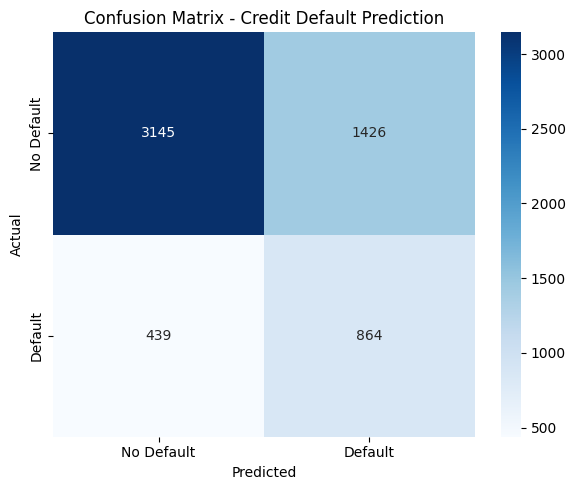

confusion matrix interpretation:
True Negatives  (TN): 3145 → correctly predicted no default
False Positives (FP): 1426 → predicted default but actually didnt
False Negatives (FN): 439 → missed actual defaulters (costly for bank!)
True Positives  (TP): 864 → correctly caught defaulters
default detection rate: 66.31%
bank loses money on false negatives - customers we missed!


In [45]:
# confusion matrix shows exactly how many predictions were correct and wrong
# this gives more detail than just accuracy number
actual = [row["label"] for row in predictions.select("label").collect()]
predicted = [row["prediction"] for row in predictions.select("prediction").collect()]

cm = confusion_matrix(actual, predicted)

# plotting confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])

plt.title("Confusion Matrix - Credit Default Prediction")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# printing interpretation of confusion matrix
# this explains what each number means in business terms
print("confusion matrix interpretation:")
print("="*50)
print(f"True Negatives  (TN): {cm[0][0]} → correctly predicted no default")
print(f"False Positives (FP): {cm[0][1]} → predicted default but actually didnt")
print(f"False Negatives (FN): {cm[1][0]} → missed actual defaulters (costly for bank!)")
print(f"True Positives  (TP): {cm[1][1]} → correctly caught defaulters")
print("="*50)
print(f"default detection rate: {round(cm[1][1]/(cm[1][0]+cm[1][1])*100, 2)}%")
print("bank loses money on false negatives - customers we missed!")

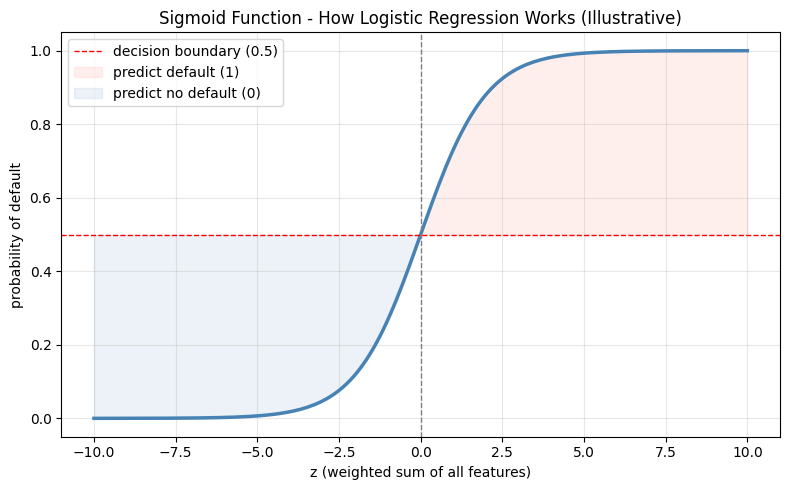

sigmoid function plotted
note: this is illustrative to show how sigmoid converts any number to probability


In [46]:
# plotting sigmoid function
# logistic regression uses sigmoid to convert weighted sum of features to probability
# formula: sigmoid(z) = 1 / (1 + e^-z)
# this is illustrative - shows how any input gets converted to probability between 0 and 1
# when probability > 0.5 model predicts default, below 0.5 predicts no default

z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, color="steelblue", linewidth=2.5)

plt.axhline(y=0.5, color="red", linestyle="--", linewidth=1, label="decision boundary (0.5)")
plt.axvline(x=0, color="gray", linestyle="--", linewidth=1)

plt.fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.1, color="tomato", label="predict default (1)")
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.1, color="steelblue", label="predict no default (0)")

plt.title("Sigmoid Function - How Logistic Regression Works (Illustrative)")
plt.xlabel("z (weighted sum of all features)")
plt.ylabel("probability of default")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sigmoid_function.png", dpi=150)
plt.show()
print("sigmoid function plotted")
print("note: this is illustrative to show how sigmoid converts any number to probability")

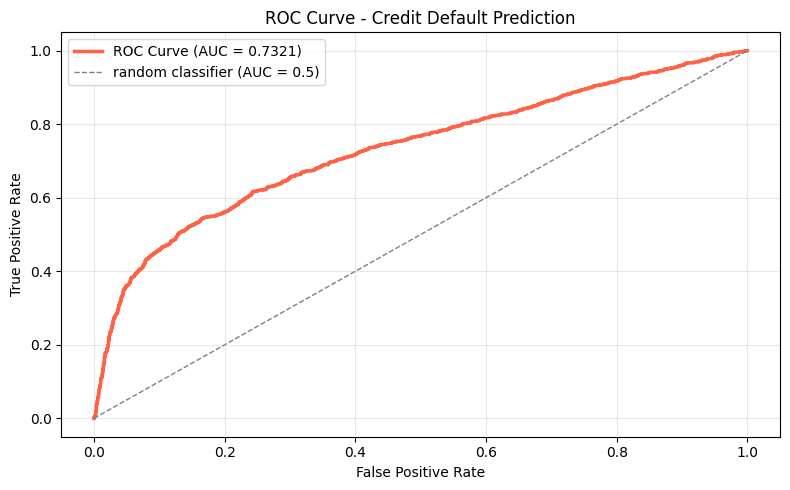

roc curve saved
our model auc: 0.7321 is above 0.7 which is good for financial data


In [47]:
# plotting roc curve to visualize model performance
# roc curve shows tradeoff between catching defaulters and false alarms
# auc = area under the curve, higher is better
# auc of 0.5 means random guessing, auc of 1.0 means perfect model
# our model auc is above 0.7 which is acceptable for real world financial data

results = predictions.select("label", "probability").rdd.map(
    lambda row: (float(row["probability"][1]), float(row["label"]))
).collect()

labels = [x[1] for x in results]
scores = [x[0] for x in results]

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color="tomato", linewidth=2.5, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="random classifier (AUC = 0.5)")
plt.title("ROC Curve - Credit Default Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print("roc curve saved")
print("our model auc:", round(roc_auc, 4), "is above 0.7 which is good for financial data")

In [49]:
# checking which features have most impact on prediction
# positive coefficient = increases chance of default
# negative coefficient = decreases chance of default
# larger absolute value = stronger impact on prediction

best_lr = cv_model.bestModel.stages[2]
coefficients = best_lr.coefficients.toArray()

# getting feature names after vectorassembler
# selected_num_cols come first, then ohe columns
coef_names = selected_num_cols + ["EDUCATION_ohe", "MARRIAGE_ohe", "SEX_ohe"]

# matching coefficients to feature names correctly
coef_df = pd.DataFrame({
    "feature": coef_names[:len(coefficients)],
    "coefficient": coefficients[:len(coef_names)]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("feature coefficients - most important first:")
print("="*45)
print(f"{'feature':<15} {'coefficient':>12}")
print("-"*45)
for _, row in coef_df.iterrows():
    direction = "increases default risk" if row["coefficient"] > 0 else "decreases default risk"
    print(f"{row['feature']:<15} {row['coefficient']:>12.4f}  ({direction})")

feature coefficients - most important first:
feature          coefficient
---------------------------------------------
PAY_1                 0.5053  (increases default risk)
PAY_AMT2             -0.1655  (decreases default risk)
PAY_AMT1             -0.1632  (decreases default risk)
MARRIAGE_ohe          0.1359  (increases default risk)
LIMIT_BAL            -0.1218  (decreases default risk)
SEX_ohe               0.1084  (increases default risk)
PAY_AMT3             -0.1039  (decreases default risk)
PAY_2                 0.0928  (increases default risk)
PAY_3                 0.0914  (increases default risk)
PAY_AMT6             -0.0610  (decreases default risk)
PAY_AMT4             -0.0564  (decreases default risk)
PAY_5                 0.0389  (increases default risk)
PAY_AMT5             -0.0368  (decreases default risk)
PAY_4                 0.0147  (increases default risk)
PAY_6                -0.0052  (decreases default risk)
EDUCATION_ohe         0.0000  (decreases default risk)


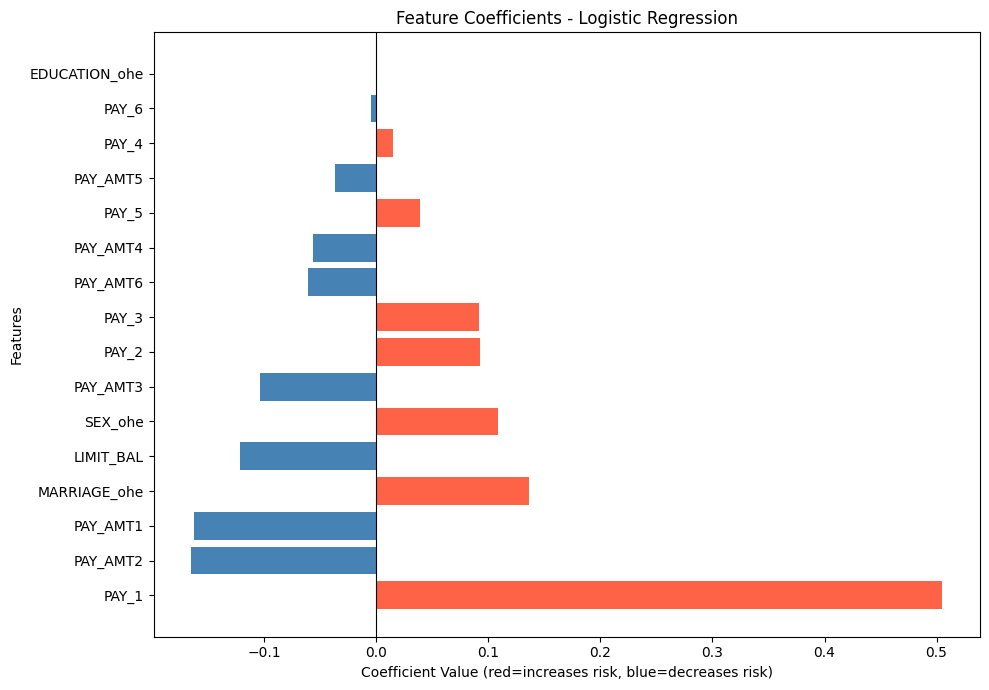

feature coefficients chart saved


In [50]:
# plotting feature coefficients as horizontal bar chart
# red bars = increases default risk
# blue bars = decreases default risk
plt.figure(figsize=(10, 7))

colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["coefficient"]]

plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)

plt.title("Feature Coefficients - Logistic Regression")
plt.xlabel("Coefficient Value (red=increases risk, blue=decreases risk)")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_coefficients.png", dpi=150)
plt.show()
print("feature coefficients chart saved")

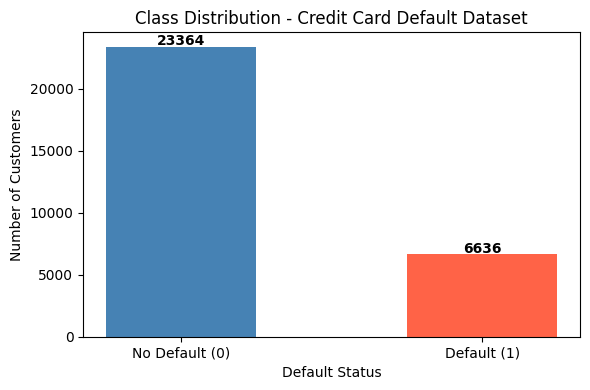

class distribution chart saved
dataset is imbalanced - this is why we used class weights in the model


In [51]:
# plotting class distribution to show the imbalance in dataset
# this is important to show why we used class weights
label_counts = df_pandas["label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["No Default (0)", "Default (1)"],
        label_counts.values,
        color=["steelblue", "tomato"],
        width=0.5)

plt.title("Class Distribution - Credit Card Default Dataset")
plt.ylabel("Number of Customers")
plt.xlabel("Default Status")

for i, v in enumerate(label_counts.values):
    plt.text(i, v + 150, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("class distribution chart saved")
print("dataset is imbalanced - this is why we used class weights in the model")

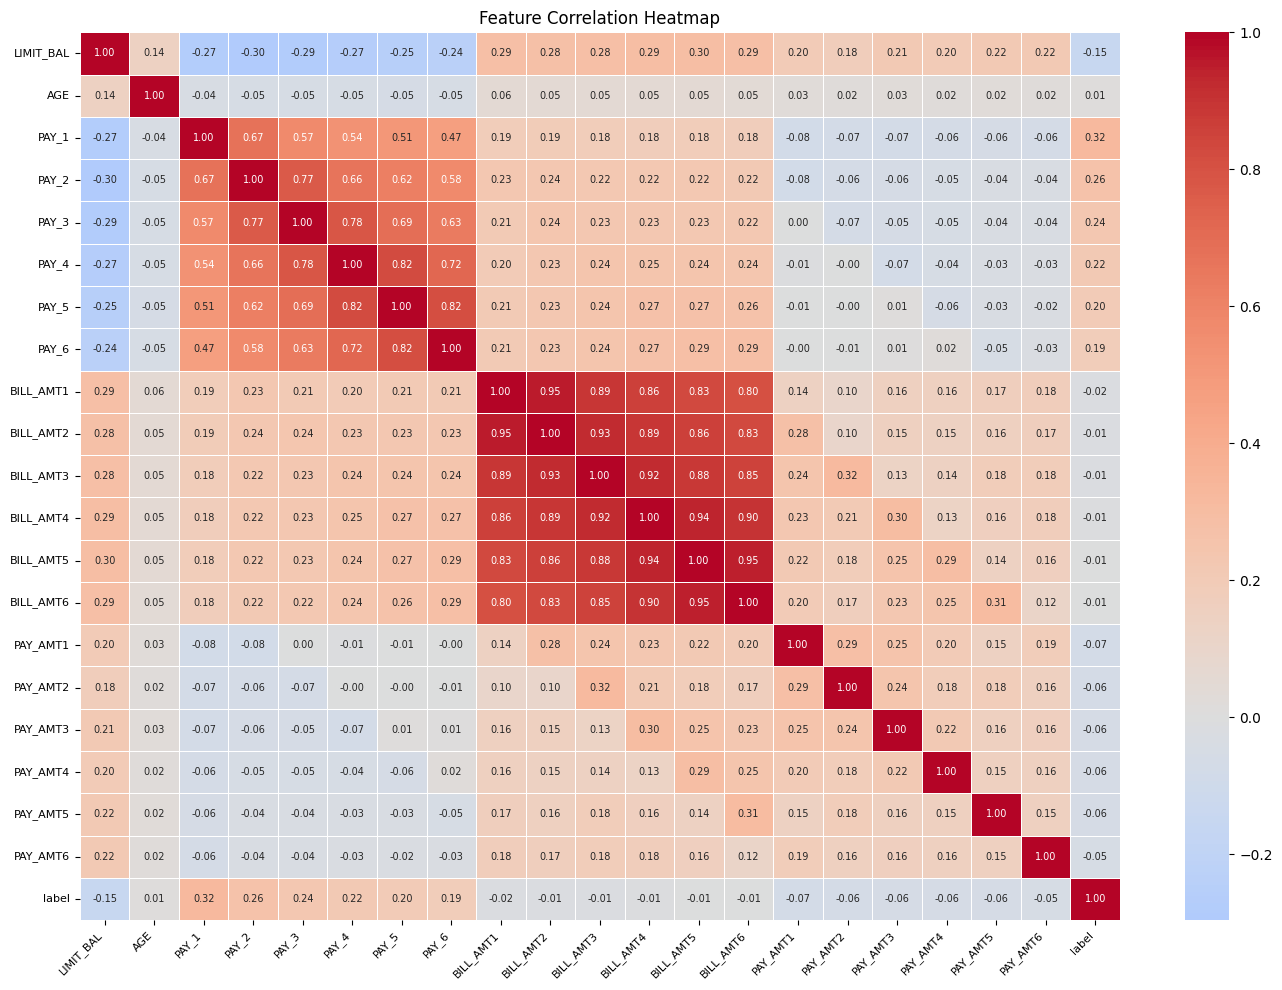

correlation heatmap saved


In [52]:
# plotting correlation heatmap to show relationships between all features
# dark red = strong positive correlation
# dark blue = strong negative correlation
# last row/column shows correlation with label (target)

plt.figure(figsize=(14, 10))

corr_matrix = df_pandas[original_cols + ["label"]].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.4,
            annot_kws={"size": 7})

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("correlation heatmap saved")

In [53]:
# saving the trained model with timestamp for versioning
# versioning is important in industry so we know which model was trained when
# if we train a new model tomorrow we can compare with todays model

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = f"credit_default_model_{timestamp}"

cv_model.bestModel.save(model_path)

print("model saved successfully!")
print("model path:", model_path)
print("timestamp used for versioning:", timestamp)
print("this allows us to track when the model was trained")

model saved successfully!
model path: credit_default_model_20260404_001848
timestamp used for versioning: 20260404_001848
this allows us to track when the model was trained


In [54]:
# loading the saved model back to confirm it works correctly
# in real world, model is trained once and loaded many times for predictions

from pyspark.ml.pipeline import PipelineModel

loaded_model = PipelineModel.load(model_path)

# making predictions with loaded model to verify it works
loaded_predictions = loaded_model.transform(test_data)

print("model loaded successfully!")
print("verifying loaded model gives same results:")
loaded_predictions.select("label", "prediction").show(5)

model loaded successfully!
verifying loaded model gives same results:
+-----+----------+
|label|prediction|
+-----+----------+
|  0.0|       0.0|
|  1.0|       0.0|
|  1.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows


In [55]:
# final summary of the complete project
print("="*50)
print("  TCS ION INDUSTRY PROJECT - COMPLETED")
print("="*50)
print("  Student   : Rakesh Ramavath")
print("  Project   : Credit Score Prediction")
print("  Algorithm : Logistic Regression (PySpark)")
print("  Dataset   : UCI Credit Card Default")
print("  Records   : 30,000 customers")
print("="*50)
print("  PIPELINE STAGES")
print("="*50)
print("  1. VectorAssembler")
print("  2. StandardScaler")
print("  3. LogisticRegression")
print("="*50)
print("  BEST HYPERPARAMETERS")
print("="*50)
print("  regParam :", best_lr.getRegParam())
print("  maxIter  :", best_lr.getMaxIter())
print("="*50)
print("  FINAL RESULTS")
print("="*50)
print("  AUC-ROC  :", auc_val)
print("  Accuracy :", acc_val)
print("  Precision:", prec_val)
print("  Recall   :", recall_val)
print("  F1 Score :", f1_val)
print("="*50)
print("  CONFUSION MATRIX")
print("="*50)
print("  True Negatives  (TN):", cm[0][0], "- correctly predicted no default")
print("  False Positives (FP):", cm[0][1], "- predicted default but didnt")
print("  False Negatives (FN):", cm[1][0], "- missed actual defaulters")
print("  True Positives  (TP):", cm[1][1], "- correctly caught defaulters")
print("="*50)
print("  CHARTS SAVED")
print("="*50)
print("  1. class_distribution.png")
print("  2. correlation_heatmap.png")
print("  3. feature_coefficients.png")
print("  4. sigmoid_function.png")
print("  5. roc_curve.png")
print("  6. confusion_matrix.png")
print("="*50)
print("  MODEL SAVED WITH VERSIONING")
print("="*50)
print("  path:", model_path)
print("="*50)
print("  PROJECT COMPLETED SUCCESSFULLY!")
print("="*50)

  TCS ION INDUSTRY PROJECT - COMPLETED
  Student   : Rakesh Ramavath
  Project   : Credit Score Prediction
  Algorithm : Logistic Regression (PySpark)
  Dataset   : UCI Credit Card Default
  Records   : 30,000 customers
  PIPELINE STAGES
  1. VectorAssembler
  2. StandardScaler
  3. LogisticRegression
  BEST HYPERPARAMETERS
  regParam : 0.01
  maxIter  : 10
  FINAL RESULTS
  AUC-ROC  : 0.7321
  Accuracy : 0.6825
  Precision: 0.7666
  Recall   : 0.6825
  F1 Score : 0.7069
  CONFUSION MATRIX
  True Negatives  (TN): 3145 - correctly predicted no default
  False Positives (FP): 1426 - predicted default but didnt
  False Negatives (FN): 439 - missed actual defaulters
  True Positives  (TP): 864 - correctly caught defaulters
  CHARTS SAVED
  1. class_distribution.png
  2. correlation_heatmap.png
  3. feature_coefficients.png
  4. sigmoid_function.png
  5. roc_curve.png
  6. confusion_matrix.png
  MODEL SAVED WITH VERSIONING
  path: credit_default_model_20260404_001848
  PROJECT COMPLETED SUC